# P0 / P1 — NIDS W5 Backbone & Income Distribution

Load NIDS Wave 5, build the household **backbone in 2017 Rands (no CPI)**, assign **per-capita
income quintiles**, and tag province. This is the recipient population for the P2 FinScope match.
`monthly_trad_repayment` is **not** computed here — it is constructed in P2 from the FinScope
product mix + external rate table. See [`../OVERVIEW.md`](../OVERVIEW.md).

## 1. Setup

In [1]:
import pandas as pd, numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
%matplotlib inline

def find_root(start=Path.cwd()):
    for d in [start, *start.parents]:
        if (d / "data" / "raw" / "NIDS_W5" / "hhderived.csv").exists():
            return d
    raise FileNotFoundError("project root not found")

ROOT = find_root()
RAW = ROOT / "data" / "raw" / "NIDS_W5" / "hhderived.csv"
PROC = ROOT / "data" / "processed"
PROC.mkdir(parents=True, exist_ok=True)
print("root:", ROOT)

root: C:\Users\marcl\OneDrive\Desktop\University\Masters\Thesis


## 2. Load

In [2]:
df = pd.read_csv(RAW)
print("raw rows:", len(df), "| cols:", df.shape[1])

raw rows: 13719 | cols: 144


## 3. Analytical sample

Keep households with **income, size, and a positive weight**; zero-fill source / rent /
balance-sheet fields (`NaN = none`).

In [3]:
core = ["w5_hhincome", "w5_hhsizer", "w5_wgt"]
hh = df[df[core].notna().all(axis=1)].copy()
hh = hh[hh["w5_wgt"] > 0]
print(f"dropped {len(df) - len(hh):,} rows -> {len(hh):,} valid households")

src_cols = ["w5_hhwage", "w5_hhgovt", "w5_hhremitt", "w5_hhother",
            "w5_hhagric", "w5_hhinvest", "w5_hhcapital"]
zero_fill = src_cols + ["w5_rentexpend", "w5_expf", "w5_expnf", "w5_f_ass", "w5_f_deb", "w5_tot_deb"]
hh[zero_fill] = hh[zero_fill].fillna(0.0)
hh["province"] = hh["w5_prov2011"]   # already province names
print("weighted population:", f"{hh['w5_wgt'].sum():,.0f}")


# --- head-of-household demographics (roster head pid -> individual-derived) ---
_ros = pd.read_stata(RAW.parent / "HouseholdRoster_W5_Anon_V1.0.0.dta",
                     columns=["w5_hhid", "pid", "w5_r_relhead"], convert_categoricals=False)
_heads = _ros[_ros["w5_r_relhead"] == 1][["w5_hhid", "pid"]]
_ind = pd.read_stata(RAW.parent / "indderived_W5_Anon_V1.0.0.dta",
                     columns=["pid", "w5_best_age_yrs", "w5_best_gen", "w5_best_race", "w5_best_edu"],
                     convert_categoricals=True)
_ind["w5_best_age_yrs"] = pd.to_numeric(_ind["w5_best_age_yrs"], errors="coerce")
_hd = _heads.merge(_ind, on="pid", how="left").rename(columns={
    "w5_best_age_yrs": "age_head", "w5_best_gen": "gender_head",
    "w5_best_race": "race_head", "w5_best_edu": "education_head"})

EDU_BAND = {
    "No Schooling": "None", "Grade R/0": "None",
    "Grade 1 (Previously Sub A/Class 1)": "Primary", "Grade 2 (Previously Sub B/Class 2)": "Primary",
    "Grade 3 (Std. 1)": "Primary", "Grade 4 (Std. 2)": "Primary", "Grade 5 (Std. 3)": "Primary",
    "Grade 6 (Std. 4)": "Primary", "Grade 7 (Std. 5)": "Primary",
    "Grade 8 (Std. 6/Form 1)": "Secondary", "Grade 9 (Std. 7/Form 2)": "Secondary",
    "Grade 10 (Std. 8/Form 3)": "Secondary", "Grade 11 (Std. 9/Form 4)": "Secondary",
    "N1 (NATED)/NTC 1": "Secondary", "N2 (NATED)/NTC 2": "Secondary", "NTC 2/NCV 3": "Secondary",
    "National Certificate Vocational 2 (NCV 2)": "Secondary",
    "Certificate not requiring Grade 12/Std. 10": "Secondary",
    "Diploma not requiring Grade 12/Std. 10": "Secondary",
    "Grade 12 (Std. 10/Matric/Senior Certificate/Form 5)": "Matric",
    "N3 (NATED)/NTC 3": "Matric", "NTC 3/NCV 4": "Matric",
    "National Certificate Vocational 3 (NCV 3)": "Matric", "National Certificate Vocational 4 (NCV 4)": "Matric",
    "Certificate requiring Grade 12/Std. 10": "Tertiary", "Diploma requiring Grade 12/Std. 10": "Tertiary",
    "Bachelors Degree": "Tertiary", "Bachelors Degree and diploma": "Tertiary",
    "Honours Degree": "Tertiary", "Higher Degree (Masters, Doctorate)": "Tertiary",
    "Don't know": "Unknown", "Others (Specify)": "Unknown",
}
_hd["education_band"] = _hd["education_head"].astype("object").map(lambda e: EDU_BAND.get(e, "Unknown"))
for col in ["gender_head", "race_head", "education_head"]:
    _hd[col] = _hd[col].astype("object").where(_hd[col].notna(), "Unknown")
hh = hh.merge(_hd.drop(columns="pid"), on="w5_hhid", how="left")
print("head demographics matched:", int(hh["age_head"].notna().sum()), "/", len(hh),
      f"| female-headed: {(hh.gender_head=='Female').mean()*100:.0f}%")

dropped 2,878 rows -> 10,841 valid households


weighted population: 18,670,046
head demographics matched: 10736 / 10841 | female-headed: 56%


## 4. Income source (dominant)

In [4]:
def income_source(r):
    vals = {"WAGE": r.w5_hhwage, "GRANT": r.w5_hhgovt,
            "OTHER": r.w5_hhremitt + r.w5_hhother + r.w5_hhagric + r.w5_hhinvest + r.w5_hhcapital}
    return "OTHER" if max(vals.values()) <= 0 else max(vals, key=vals.get)
hh["income_source"] = hh.apply(income_source, axis=1)
hh["income_source"].value_counts()

income_source
WAGE     5581
OTHER    2660
GRANT    2600
Name: count, dtype: int64

## 5. Expenditure split
committed = food + rent; discretionary = total − committed (≥0).

In [5]:
hh["expenditure_total"]         = hh["w5_expenditure"]
hh["expenditure_committed"]     = hh["w5_expf"] + hh["w5_rentexpend"]
hh["expenditure_discretionary"] = (hh["expenditure_total"] - hh["expenditure_committed"]).clip(lower=0)
hh[["expenditure_total", "expenditure_committed", "expenditure_discretionary"]].describe().round(0)

,expenditure_total,expenditure_committed,expenditure_discretionary
count,10841.0,10841.0,10841.0
mean,8014.0,1871.0,6143.0
std,15115.0,2927.0,13729.0
min,238.0,30.0,0.0
25%,2036.0,800.0,1057.0
50%,3457.0,1200.0,2105.0
75%,7216.0,2000.0,5082.0
max,456717.0,200000.0,444717.0


## 6. Balance sheet

- `liquid_savings` = financial assets (`w5_f_ass`), **winsorized at the 99th percentile** (a few
  households report assets up to ~R350m; capping prevents these from distorting buffers). Documented limitation.
- `D_trad` = financial debts (`w5_f_deb`).
- `monthly_trad_repayment` is deferred to **P2** (needs FinScope product mix + external rate table).

In [6]:
hi = hh["w5_f_ass"].quantile(0.99)
n_capped = int((hh["w5_f_ass"] > hi).sum())
hh["liquid_savings"] = hh["w5_f_ass"].clip(upper=hi)
hh["D_trad"] = hh["w5_f_deb"]
print(f"winsorized liquid_savings at 99th pct = R{hi:,.0f}  ({n_capped} households capped)")
hh[["liquid_savings", "D_trad"]].describe().round(0)

winsorized liquid_savings at 99th pct = R133,662  (109 households capped)


,liquid_savings,D_trad
count,10841.0,10841.0
mean,3836.0,8960.0
std,16252.0,54706.0
min,0.0,0.0
25%,0.0,0.0
50%,20.0,0.0
75%,966.0,2600.0
max,133662.0,2585000.0


## 7. Per-capita income & weighted quintiles
Quintiles cut on per-capita income (income ÷ size), weighted so each holds ~20% of households.

In [7]:
hh["income_pc"] = hh["w5_hhincome"] / hh["w5_hhsizer"]

def weighted_quintiles(values, weights, q=5):
    order = np.argsort(values.values)
    v, w = values.values[order], weights.values[order]
    cum = np.cumsum(w) / w.sum()
    cuts = [np.searchsorted(cum, i / q) for i in range(1, q)]
    bounds = [v[min(c, len(v) - 1)] for c in cuts]
    edges = [-np.inf] + bounds + [np.inf]
    return pd.cut(values, bins=edges, labels=[f"Q{i}" for i in range(1, q + 1)], include_lowest=True), bounds

hh["income_quintile"], pc_bounds = weighted_quintiles(hh["income_pc"], hh["w5_wgt"])
print("per-capita quintile bounds (R/month, 2017):", [round(b, 1) for b in pc_bounds])

per-capita quintile bounds (R/month, 2017): [np.float64(900.0), np.float64(1801.4), np.float64(3400.0), np.float64(7712.1)]


## 8. Consistency checks

In [8]:
shares = hh.groupby("income_quintile", observed=True)["w5_wgt"].sum() / hh["w5_wgt"].sum()
print("weighted share by quintile (target 0.20):"); print(shares.round(3).to_string())

weighted share by quintile (target 0.20):
income_quintile
Q1    0.204
Q2    0.196
Q3    0.201
Q4    0.199
Q5    0.200


In [9]:
def wmean(s, w): return np.average(s, weights=w)
rows = []
for q, d in hh.groupby("income_quintile", observed=True):
    w = d["w5_wgt"].values
    rows.append({"quintile": q, "n": len(d),
        "mean_hh_income": wmean(d.w5_hhincome, w), "mean_pc_income": wmean(d.income_pc, w),
        "mean_committed": wmean(d.expenditure_committed, w),
        "mean_discretionary": wmean(d.expenditure_discretionary, w),
        "pct_with_debt": np.average(d.D_trad > 0, weights=w) * 100,
        "pct_with_savings": np.average(d.liquid_savings > 0, weights=w) * 100})
summary = pd.DataFrame(rows).set_index("quintile"); summary.round(1)

,n,mean_hh_income,mean_pc_income,mean_committed,mean_discretionary,pct_with_debt,pct_with_savings
quintile,,,,,,,
Q1,3034,2590.4,564.6,1064.7,1676.0,32.5,31.0
Q2,2706,4827.6,1330.8,1262.3,2715.8,41.8,46.9
Q3,2071,6641.2,2507.7,1569.3,3363.1,45.7,57.4
Q4,1599,10443.1,5043.6,2132.0,6097.3,49.6,67.9
Q5,1431,37760.5,21420.9,4612.7,21381.3,50.9,75.6


In [10]:
comp = pd.crosstab(hh.income_quintile, hh.income_source, values=hh.w5_wgt, aggfunc="sum", normalize="index") * 100
comp.round(1)

income_source,GRANT,OTHER,WAGE
income_quintile,,,
Q1,44.2,27.0,28.8
Q2,19.6,26.5,53.9
Q3,9.5,21.9,68.6
Q4,2.4,20.4,77.2
Q5,0.5,30.6,69.0


## 9. Plots

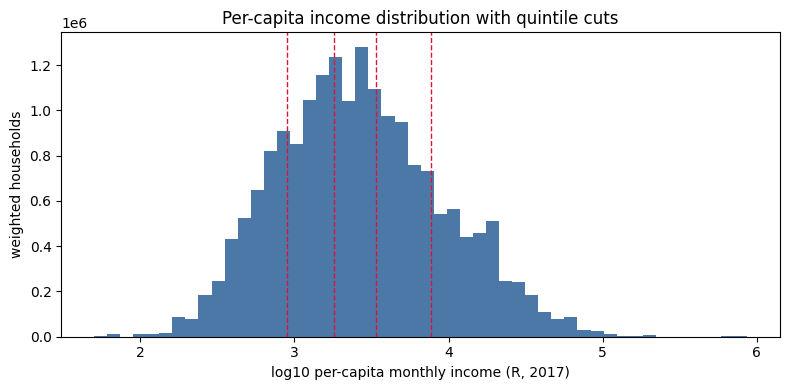

In [11]:
fig, ax = plt.subplots(figsize=(8, 4))
mask = hh.income_pc > 0
ax.hist(np.log10(hh.income_pc[mask]), bins=50, weights=hh.w5_wgt[mask], color="#4C78A8")
for b in pc_bounds: ax.axvline(np.log10(b), color="crimson", ls="--", lw=1)
ax.set_xlabel("log10 per-capita monthly income (R, 2017)"); ax.set_ylabel("weighted households")
ax.set_title("Per-capita income distribution with quintile cuts"); plt.tight_layout(); plt.show()

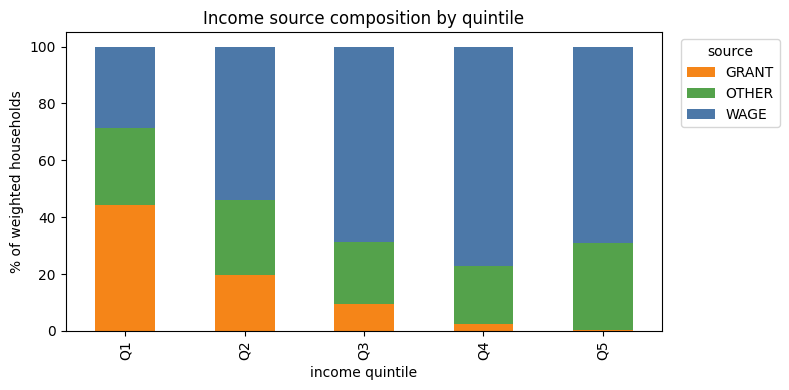

In [12]:
fig, ax = plt.subplots(figsize=(8, 4))
comp.plot(kind="bar", stacked=True, ax=ax, color={"WAGE": "#4C78A8", "GRANT": "#F58518", "OTHER": "#54A24B"})
ax.set_xlabel("income quintile"); ax.set_ylabel("% of weighted households")
ax.set_title("Income source composition by quintile")
ax.legend(title="source", bbox_to_anchor=(1.02, 1), loc="upper left"); plt.tight_layout(); plt.show()

## 9b. Head-of-household demographics

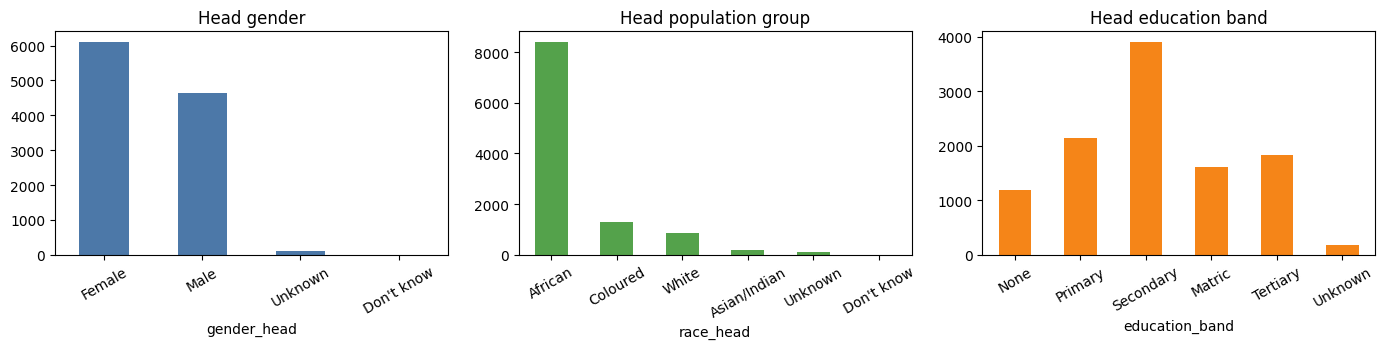

weighted mean head age by quintile:
  Q1: 45.3
  Q2: 45.4
  Q3: 42.0
  Q4: 40.4
  Q5: 44.0


In [13]:
fig, axes = plt.subplots(1, 3, figsize=(14, 3.6))
hh.gender_head.value_counts().plot(kind="bar", ax=axes[0], color="#4C78A8"); axes[0].set_title("Head gender")
hh.race_head.value_counts().plot(kind="bar", ax=axes[1], color="#54A24B"); axes[1].set_title("Head population group")
order = ["None", "Primary", "Secondary", "Matric", "Tertiary", "Unknown"]
hh.education_band.value_counts().reindex(order).dropna().plot(kind="bar", ax=axes[2], color="#F58518")
axes[2].set_title("Head education band")
for ax in axes: ax.tick_params(axis="x", rotation=30)
plt.tight_layout(); plt.show()
print("weighted mean head age by quintile:")
for q, d in hh.groupby("income_quintile", observed=True):
    dd = d.dropna(subset=["age_head"]); print(f"  {q}: {np.average(dd.age_head, weights=dd.w5_wgt):.1f}")

## 10. Persist backbone

In [14]:
import json
keep = ["w5_hhid", "w5_wgt", "w5_hhsizer", "province", "w5_hhincome", "income_pc", "income_quintile",
        "income_source", "expenditure_total", "expenditure_committed", "expenditure_discretionary",
        "liquid_savings", "D_trad",
        "age_head", "gender_head", "race_head", "education_head", "education_band"]
backbone = hh[keep].copy()
backbone.to_parquet(PROC / "nids_backbone.parquet", index=False)
backbone.head(50).to_csv(PROC / "nids_backbone_preview.csv", index=False)
summary_json = {"reference_year": 2017, "n_households": int(len(backbone)),
    "weighted_population": float(hh["w5_wgt"].sum()),
    "pc_income_quintile_bounds": [round(float(b), 2) for b in pc_bounds],
    "weighted_quintile_shares": {k: round(float(v), 4) for k, v in shares.items()},
    "liquid_savings_winsor_99pct": float(hi),
    "head_demographics_coverage": int(hh["age_head"].notna().sum())}
(PROC / "nids_backbone_summary.json").write_text(json.dumps(summary_json, indent=2))
print(json.dumps(summary_json, indent=2))

{
  "reference_year": 2017,
  "n_households": 10841,
  "weighted_population": 18670046.380067,
  "pc_income_quintile_bounds": [
    900.0,
    1801.42,
    3400.0,
    7712.14
  ],
  "weighted_quintile_shares": {
    "Q1": 0.2044,
    "Q2": 0.1957,
    "Q3": 0.2011,
    "Q4": 0.1988,
    "Q5": 0.1999
  },
  "liquid_savings_winsor_99pct": 133662.35000000166,
  "head_demographics_coverage": 10736
}


Next — **P2**: `p2_finscope_match.ipynb`.